# Computational Analysis of EEG-Derived Features Across Emotional States

## Introduction

Electroencephalography (EEG) provides a non-invasive means of measuring electrical activity associated with brain function. Because EEG signals can vary across cognitive and emotional states, they provide a useful source of data for computational investigation of neural activity.

This project analyzes the SAM40 dataset, which contains high-dimensional features extracted from EEG recordings collected during experimental tasks designed to elicit different cognitive and emotional states. The dataset represents three observed classes: negative, neutral, and positive. Rather than working directly with continuous EEG signals, this analysis focuses on pre-extracted features that summarize different properties of the recorded neural activity.

The aim of this analysis is to investigate the structure and characteristics of these EEG-derived features and determine whether they contain systematic patterns associated with the observed classes. The project will follow a data-driven approach, combining exploratory data analysis, data-quality assessment, statistical analysis, and appropriate preprocessing before applying dimensionality reduction and computational classification where justified by the data.

Particular attention will be given to feature distributions, variability, redundancy, and relationships among feature families. The analysis will also consider the limitations of working with pre-extracted EEG features and evaluate how reliably computational methods can distinguish between the observed classes.

## Study Objectives and Analytical Framework

### Objectives

The objectives of this project are to:

1. Characterize the structure and statistical properties of the EEG-derived feature space.

2. Assess the quality of the dataset by examining missing values, infinite values, duplicate features, distributions, skewness, and variability.

3. Investigate feature redundancy and relationships among the different EEG-derived feature families.

4. Examine whether the feature space contains systematic patterns associated with the negative, neutral, and positive classes.

5. Apply appropriate preprocessing and dimensionality-reduction techniques based on the statistical characteristics of the feature space.

6. Develop and evaluate computational classification models for distinguishing between the three observed classes.

7. Compare model performance using appropriate evaluation metrics and assess the generalizability and limitations of the resulting models.


### Research Question

Do EEG-derived features contain systematic patterns that can distinguish between negative, neutral, and positive emotional states?

### Hypotheses

**Null Hypothesis (H₀):** EEG-derived features do not contain systematic differences that distinguish between the three emotional-state classes.

**Alternative Hypothesis (H₁):** EEG-derived features contain systematic differences that distinguish between the three emotional-state classes.

### Dataset and Analytical Approach

The analysis uses the SAM40 dataset, in which each observation is represented by extracted numerical features rather than raw continuous EEG recordings. The feature space contains several groups of measurements, including mean, standard deviation, moment-based, maximum, minimum, covariance-matrix, eigenvalue, matrix-logarithm, entropy, correlation, and fast Fourier transform (FFT)-based features. These feature groups provide different numerical representations of characteristics derived from the underlying EEG signals.

The analysis will proceed from data-quality assessment and exploratory feature analysis to appropriate preprocessing, feature reduction, statistical investigation, and computational classification. Methodological decisions will be guided by the characteristics of the dataset and the research question, allowing the analytical approach to adapt to the structure and statistical properties observed in the data.

## Libraries and Environment

In [1]:
# Core libraries for data manipulation, numerical analysis, and visualization

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading and Initial Assessment

In [2]:
# Load the EEG-derived feature dataset

df_raw = pd.read_csv(
    "/kaggle/input/datasets/prashantgehlot2404/eeg-dataset-stress-detection/emotions.csv"
)

df_raw.head()

,# mean_0_a,mean_1_a,mean_2_a,mean_3_a,mean_4_a,mean_d_0_a,mean_d_1_a,mean_d_2_a,mean_d_3_a,mean_d_4_a,...,fft_741_b,fft_742_b,fft_743_b,fft_744_b,fft_745_b,fft_746_b,fft_747_b,fft_748_b,fft_749_b,label
0,4.62,30.3,-356.0,15.6,26.3,1.070,0.411,-15.70,2.06,3.15,...,23.5,20.3,20.3,23.5,-215.0,280.00,-162.00,-162.00,280.00,NEGATIVE
1,28.80,33.1,32.0,25.8,22.8,6.550,1.680,2.88,3.83,-4.82,...,-23.3,-21.8,-21.8,-23.3,182.0,2.57,-31.60,-31.60,2.57,NEUTRAL
2,8.90,29.4,-416.0,16.7,23.7,79.900,3.360,90.20,89.90,2.03,...,462.0,-233.0,-233.0,462.0,-267.0,281.00,-148.00,-148.00,281.00,POSITIVE
3,14.90,31.6,-143.0,19.8,24.3,-0.584,-0.284,8.82,2.30,-1.97,...,299.0,-243.0,-243.0,299.0,132.0,-12.40,9.53,9.53,-12.40,POSITIVE
4,28.30,31.3,45.2,27.3,24.5,34.800,-5.790,3.06,41.40,5.52,...,12.0,38.1,38.1,12.0,119.0,-17.60,23.90,23.90,-17.60,NEUTRAL


In [3]:
# Inspect the dimensions of the dataset

df_raw.shape

(2132, 2549)

In [4]:
# Examine the data types of the dataset columns

df_raw.dtypes.value_counts()

float64    2548
object        1
Name: count, dtype: int64

In [5]:
# Identify non-numerical columns

df_raw.select_dtypes(exclude="number").columns

Index(['label'], dtype='object')

In [6]:
# Examine the distribution of emotional-state labels

df_raw["label"].value_counts()

label
NEUTRAL     716
NEGATIVE    708
POSITIVE    708
Name: count, dtype: int64

In [7]:
# Check the total number of missing values

df_raw.isnull().sum().sum()

np.int64(0)

In [8]:
# Identify columns containing missing values

missing_values = df_raw.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [9]:
# Check for completely duplicated observations

duplicate_rows = df_raw.duplicated().sum()

duplicate_rows

np.int64(0)

In [10]:
# Identify duplicated feature columns

feature_data = df_raw.drop(columns="label")

duplicated_features = feature_data.T.duplicated()

duplicated_features.sum()

np.int64(732)

In [11]:
# Identify the names of duplicated feature columns

duplicated_feature_names = feature_data.columns[duplicated_features]

duplicated_feature_names[:30]

Index(['covmat_12_a', 'covmat_24_a', 'covmat_25_a', 'covmat_36_a',
       'covmat_37_a', 'covmat_38_a', 'covmat_48_a', 'covmat_49_a',
       'covmat_50_a', 'covmat_51_a', 'covmat_60_a', 'covmat_61_a',
       'covmat_62_a', 'covmat_63_a', 'covmat_64_a', 'covmat_72_a',
       'covmat_73_a', 'covmat_74_a', 'covmat_75_a', 'covmat_76_a',
       'covmat_77_a', 'covmat_84_a', 'covmat_85_a', 'covmat_86_a',
       'covmat_87_a', 'covmat_88_a', 'covmat_89_a', 'covmat_90_a',
       'covmat_96_a', 'covmat_97_a'],
      dtype='object')

In [12]:
# Examine duplicated features by feature family

duplicated_families = (duplicated_feature_names
     .str.extract(r'^([a-zA-Z]+)')[0]
    .value_counts()
)

duplicated_families

0
fft       600
covmat    132
Name: count, dtype: int64

### Initial Data Quality Findings

The dataset contains 2,132 observations and 2,548 EEG-derived numerical features, with no missing values or completely duplicated observations. The three emotional-state classes are also approximately balanced.

However, the feature space contains substantial redundancy. Of the 2,548 feature columns, 732 are exact duplicates. This redundancy is concentrated within two feature families: FFT-derived features account for 600 duplicated columns, while covariance-matrix features account for 132. These findings will be considered when defining the preprocessing and feature-reduction strategy.

## Exploratory Data Analysis (EDA)

This stage examines the structure and characteristics of the EEG-derived feature space before preprocessing and modelling. The analysis investigates the composition of the extracted features, their distributions, skewness, redundancy, correlations, and patterns across the negative, neutral, and positive emotional-state classes.

The purpose of this exploration is to understand the quality and structure of the data and identify characteristics that may influence subsequent statistical analysis and computational modelling. These observations will guide the preprocessing and feature-reduction decisions made in the next stage.

In [13]:
# Identify the feature family of each EEG-derived feature

feature_families = (
    feature_data.columns
    .str.extract(r'^#?\s*([a-zA-Z]+)')[0]
    .value_counts()
)

feature_families

0
fft          1500
covmat        288
logm          156
correlate     150
max           120
mean          120
min           120
moments        40
eigen          24
stddev         20
entropy        10
Name: count, dtype: int64

In [14]:
# Inspect representative feature names from the main feature families

families_to_check = ["mean", "stddev", "moments", "entropy", "fft"]

for family in families_to_check:
    matching_columns = feature_data.columns[
        feature_data.columns.str.contains(
            rf"^(?:#\s*)?{family}",
            case=False,
            regex=True
        )
    ]

    print(f"\n{family.upper()} features:")
    print(matching_columns[:5].tolist())


MEAN features:
['# mean_0_a', 'mean_1_a', 'mean_2_a', 'mean_3_a', 'mean_4_a']

STDDEV features:
['stddev_0_a', 'stddev_1_a', 'stddev_2_a', 'stddev_3_a', 'stddev_4_a']

MOMENTS features:
['moments_0_a', 'moments_1_a', 'moments_2_a', 'moments_3_a', 'moments_4_a']

ENTROPY features:
['entropy0_a', 'entropy1_a', 'entropy2_a', 'entropy3_a', 'entropy4_a']

FFT features:
['fft_0_a', 'fft_1_a', 'fft_2_a', 'fft_3_a', 'fft_4_a']


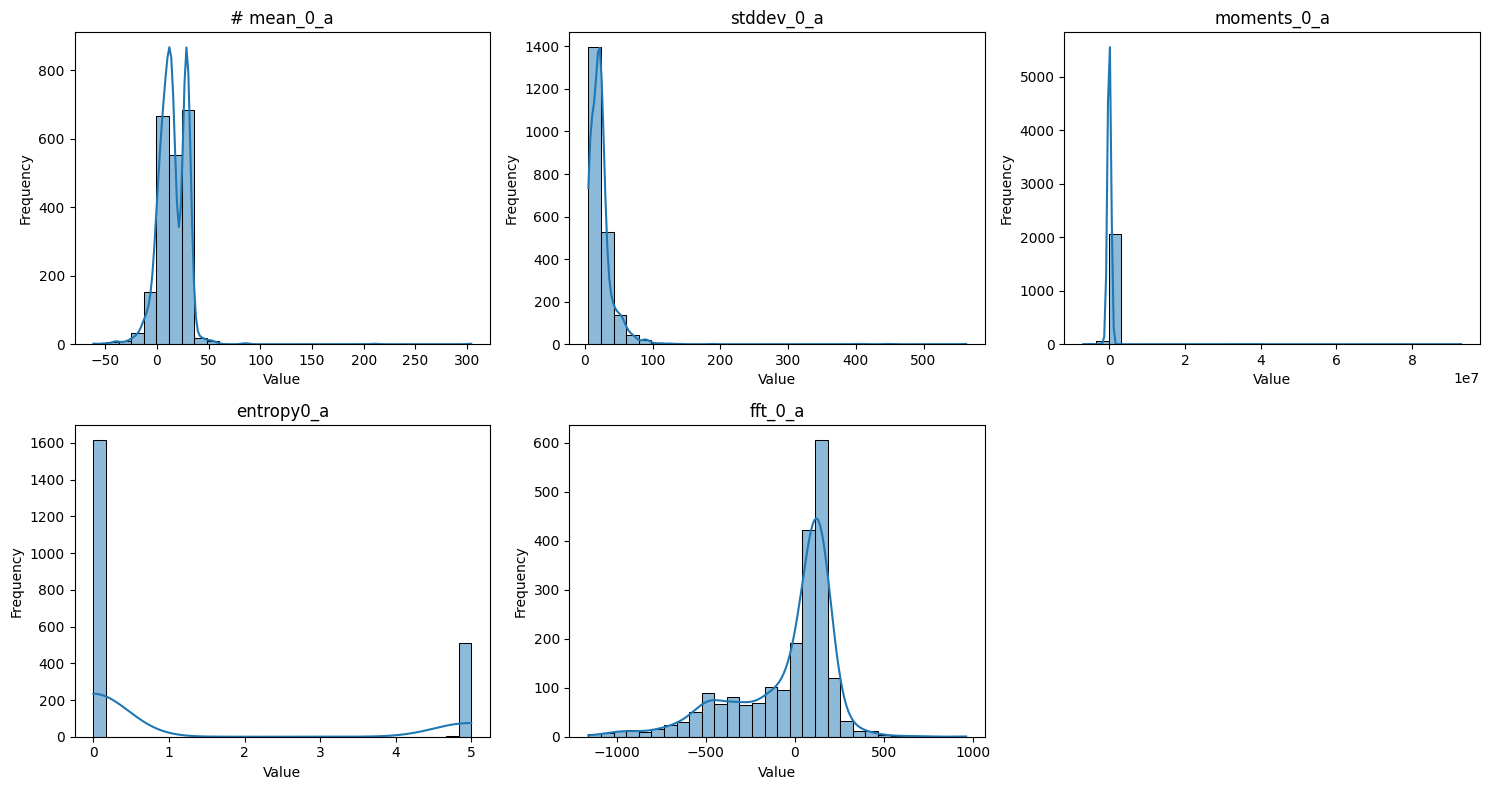

In [15]:
# Select representative features from different feature families

selected_features = [
    "# mean_0_a",
    "stddev_0_a",
    "moments_0_a",
    "entropy0_a",
    "fft_0_a"
]

# Visualize distributions using histograms and KDE curves

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(selected_features):
    sns.histplot(
        data=df_raw,
        x=feature,
        kde=True,
        bins=30,
        ax=axes[i]
    )
    axes[i].set_title(feature)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

# Hide the unused sixth subplot
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

In [16]:
# Calculate skewness for the representative features

skewness = df_raw[selected_features].skew()

skewness.sort_values()

fft_0_a        -1.312634
entropy0_a      1.211518
# mean_0_a      3.839961
stddev_0_a     11.338843
moments_0_a    38.000041
dtype: float64

In [17]:
# Select representative features for correlation analysis

correlation_features = [
    "# mean_0_a",
    "stddev_0_a",
    "moments_0_a",
    "entropy0_a",
    "fft_0_a"
]

correlation_matrix = df_raw[correlation_features].corr()

correlation_matrix

,# mean_0_a,stddev_0_a,moments_0_a,entropy0_a,fft_0_a
# mean_0_a,1.000000,0.061864,0.276256,0.541994,0.377758
stddev_0_a,0.061864,1.000000,0.433899,-0.362062,-0.205444
moments_0_a,0.276256,0.433899,1.000000,-0.008823,-0.022570
entropy0_a,0.541994,-0.362062,-0.008823,1.000000,0.377231
fft_0_a,0.377758,-0.205444,-0.022570,0.377231,1.000000


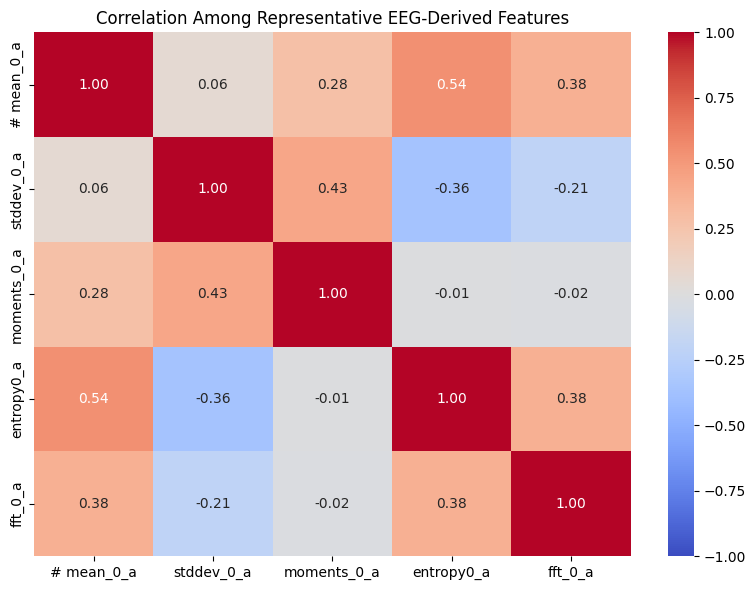

In [18]:
# Visualize correlations among representative EEG-derived features

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Among Representative EEG-Derived Features")
plt.tight_layout()
plt.show()

In [19]:
# Select representative features for class-based exploration

selected_features = [
    "# mean_0_a",
    "stddev_0_a",
    "moments_0_a",
    "entropy0_a",
    "fft_0_a"
]

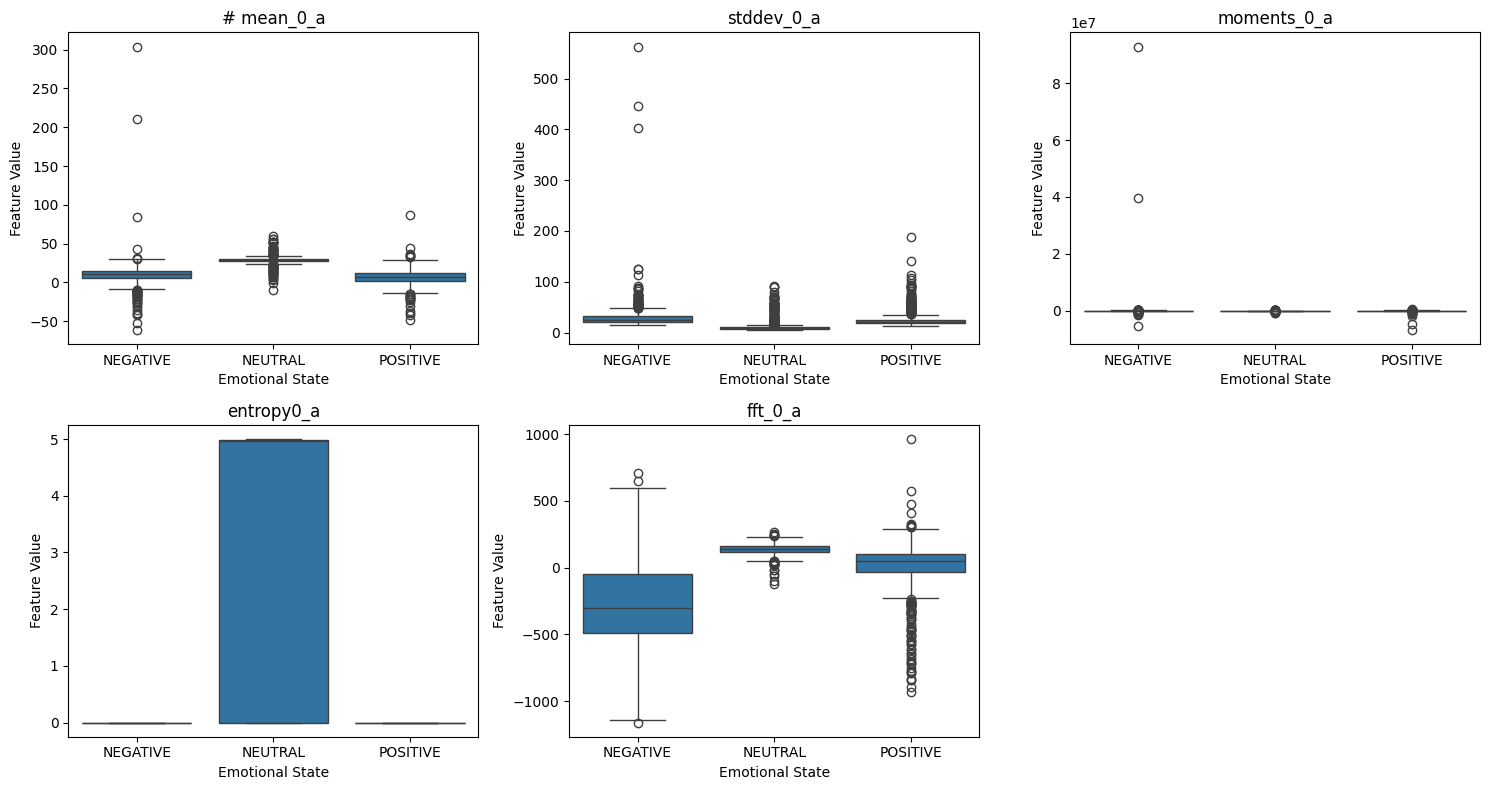

In [20]:
# Compare representative EEG-derived features across emotional states

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(selected_features):
    sns.boxplot(
        data=df_raw,
        x="label",
        y=feature,
        ax=axes[i]
    )
    
    axes[i].set_title(feature)
    axes[i].set_xlabel("Emotional State")
    axes[i].set_ylabel("Feature Value")

axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

In [21]:
# Compare median feature values across emotional-state classes

class_medians = df_raw.groupby("label")[selected_features].median().T

class_medians

label,NEGATIVE,NEUTRAL,POSITIVE
# mean_0_a,11.55,28.900,7.425
stddev_0_a,25.30,8.480,21.300
moments_0_a,-359.00,-4.955,-1825.000
entropy0_a,0.00,4.970,0.000
fft_0_a,-303.50,141.000,50.000


### Interpretation of Exploratory Analysis

The exploratory analysis revealed that the dataset contains 2,548 EEG-derived features spanning multiple feature families, with FFT-derived features representing the largest proportion of the feature space. The feature distributions were highly heterogeneous, with several features exhibiting substantial skewness and extreme values. The analysis also identified 732 exact duplicate feature columns, indicating considerable redundancy within the original feature space.

Correlation analysis among representative features showed varying degrees of association rather than uniformly strong relationships. Comparison across the negative, neutral, and positive emotional-state classes revealed differences in the median values of several representative features, although substantial overlap and within-class variability remained.

Overall, the EDA indicates that the dataset contains potentially informative patterns related to emotional state, but also presents substantial redundancy, skewed distributions, outliers, and high dimensionality. These characteristics motivate the need for careful preprocessing and feature reduction before subsequent statistical and computational modelling.

## Data Preprocessing and Feature Reduction

The exploratory analysis identified substantial feature redundancy, skewed distributions, extreme values, and a high-dimensional feature space. This stage prepares the EEG-derived features for subsequent statistical analysis and computational modelling while preserving the original dataset.

A working copy will be used for preprocessing, beginning with the removal of exact duplicate features. Further preprocessing and feature-reduction decisions will be guided by the characteristics identified during exploratory analysis.

In [22]:
# Create a working copy for preprocessing

df = df_raw.copy()

df.head()

,# mean_0_a,mean_1_a,mean_2_a,mean_3_a,mean_4_a,mean_d_0_a,mean_d_1_a,mean_d_2_a,mean_d_3_a,mean_d_4_a,...,fft_741_b,fft_742_b,fft_743_b,fft_744_b,fft_745_b,fft_746_b,fft_747_b,fft_748_b,fft_749_b,label
0,4.62,30.3,-356.0,15.6,26.3,1.070,0.411,-15.70,2.06,3.15,...,23.5,20.3,20.3,23.5,-215.0,280.00,-162.00,-162.00,280.00,NEGATIVE
1,28.80,33.1,32.0,25.8,22.8,6.550,1.680,2.88,3.83,-4.82,...,-23.3,-21.8,-21.8,-23.3,182.0,2.57,-31.60,-31.60,2.57,NEUTRAL
2,8.90,29.4,-416.0,16.7,23.7,79.900,3.360,90.20,89.90,2.03,...,462.0,-233.0,-233.0,462.0,-267.0,281.00,-148.00,-148.00,281.00,POSITIVE
3,14.90,31.6,-143.0,19.8,24.3,-0.584,-0.284,8.82,2.30,-1.97,...,299.0,-243.0,-243.0,299.0,132.0,-12.40,9.53,9.53,-12.40,POSITIVE
4,28.30,31.3,45.2,27.3,24.5,34.800,-5.790,3.06,41.40,5.52,...,12.0,38.1,38.1,12.0,119.0,-17.60,23.90,23.90,-17.60,NEUTRAL


In [23]:
# Separate EEG-derived features from the target variable

X = df.drop(columns="label")
y = df["label"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (2132, 2548)
Target shape: (2132,)


In [24]:
# Remove exact duplicate feature columns

X = X.loc[:, ~X.T.duplicated()]

print("Feature matrix shape after removing duplicates:", X.shape)

Feature matrix shape after removing duplicates: (2132, 1816)


In [25]:
# Verify that no exact duplicate feature columns remain

remaining_duplicates = X.T.duplicated().sum()

print("Remaining duplicated feature columns:", remaining_duplicates)

Remaining duplicated feature columns: 0


In [26]:
# Check for missing values in the cleaned feature matrix

missing_values = X.isna().sum().sum()

print("Total missing values:", missing_values)

Total missing values: 0


In [27]:
# Check for infinite values in the cleaned feature matrix

infinite_values = np.isinf(X).sum().sum()

print("Total infinite values:", infinite_values)

Total infinite values: 0


In [28]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.20,
                                                    stratify=y,random_state=42)

In [29]:
# Check the dimensions of the training and testing sets

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1705, 1816)
X_test shape: (427, 1816)
y_train shape: (1705,)
y_test shape: (427,)


In [30]:
# Check class distribution in the training and testing sets

print("Training class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training class distribution:
label
NEUTRAL     573
NEGATIVE    566
POSITIVE    566
Name: count, dtype: int64

Testing class distribution:
label
NEUTRAL     143
POSITIVE    142
NEGATIVE    142
Name: count, dtype: int64


In [31]:
# Import preprocessing tools

from sklearn.preprocessing import QuantileTransformer, RobustScaler

In [32]:
# Identify moment-based features

moment_features = [
    col for col in X_train.columns
    if col.replace("# ", "").startswith("moments")
]

print("Number of moments features:", len(moment_features))

# Identify all remaining EEG-derived features

other_features = [
    col for col in X_train.columns
    if col not in moment_features
]

print("Number of other features:", len(other_features))

Number of moments features: 40
Number of other features: 1776


In [33]:
# Create separate transformers for the two feature groups

moment_transformer = QuantileTransformer(
    output_distribution="normal",
    random_state=42
)

other_transformer = RobustScaler()

In [34]:
# Fit the transformers using training data only

moment_transformer.fit(X_train[moment_features])
other_transformer.fit(X_train[other_features])

RobustScaler()

In [35]:
# Transform the moments features

X_train_moments = moment_transformer.transform( X_train[moment_features])

X_test_moments = moment_transformer.transform(X_test[moment_features])

# Transform the remaining features

X_train_other = other_transformer.transform(X_train[other_features])

X_test_other = other_transformer.transform(X_test[other_features])

In [36]:
# Recombine the transformed feature groups

X_train_preprocessed = np.hstack([X_train_moments,X_train_other])

X_test_preprocessed = np.hstack([X_test_moments,X_test_other])

In [37]:
# Check the shape of the preprocessed datasets

print("Preprocessed training shape:", X_train_preprocessed.shape)
print("Preprocessed testing shape:", X_test_preprocessed.shape)

Preprocessed training shape: (1705, 1816)
Preprocessed testing shape: (427, 1816)


In [38]:
# Check the range of the preprocessed training features

print("Minimum preprocessed value:", np.min(X_train_preprocessed))
print("Maximum preprocessed value:", np.max(X_train_preprocessed))
print("Largest absolute preprocessed value:",np.max(np.abs(X_train_preprocessed)))

Minimum preprocessed value: -6748.039971784623
Maximum preprocessed value: 4409.403937007882
Largest absolute preprocessed value: 6748.039971784623


In [39]:
# Find the feature responsible for the largest absolute preprocessed value

max_position = np.unravel_index(np.argmax(np.abs(X_train_preprocessed)),
    X_train_preprocessed.shape)

print("Row:", max_position[0])
print("Column:", max_position[1])
print("Largest absolute value:", X_train_preprocessed[max_position])

# Recreate the feature-name order used in the preprocessed matrix

preprocessed_feature_names = moment_features + other_features

print("Feature with largest absolute value:",
    preprocessed_feature_names[max_position[1]])

Row: 1404
Column: 257
Largest absolute value: -6748.039971784623
Feature with largest absolute value: covmat_30_a


In [40]:
# Inspect the distribution of the covmat_30_a feature after RobustScaler

covmat_30_index = other_features.index("covmat_30_a")

covmat_30_scaled = X_train_other[:, covmat_30_index]

print("Minimum:", np.min(covmat_30_scaled))
print("Maximum:", np.max(covmat_30_scaled))
print("Median:", np.median(covmat_30_scaled))
print("99th percentile:", np.percentile(covmat_30_scaled, 99))
print("1st percentile:", np.percentile(covmat_30_scaled, 1))

Minimum: -6748.039971784623
Maximum: 404.55819421584766
Median: 0.0
99th percentile: 16.523395250411475
1st percentile: -97.35574888314133


In [41]:
# Examine severe skewness by feature family

skewness = X_train.skew()

family_labels = X_train.columns.str.extract(r"^([A-Za-z]+)")[0]

skewness_by_family = (pd.DataFrame({
        "family": family_labels,
        "skewness": skewness}))

skewness_by_family["high_skew"] = (skewness_by_family["skewness"].abs() > 5)

print(skewness_by_family
    .groupby("family")["high_skew"]
    .agg(["sum", "count"])
    .sort_values("sum", ascending=False)
)

           sum  count
family               
correlate    0    150
covmat       0    156
eigen        0     24
entropy      0     10
fft          0    900
logm         0    156
max          0    120
mean         0    119
min          0    120
moments      0     40
stddev       0     20


In [42]:
# Count extreme values in the preprocessed training matrix

for threshold in [10, 100, 1000]:
    count = np.sum(np.abs(X_train_preprocessed) > threshold)
    print(f"Values with absolute magnitude > {threshold}: {count}")

Values with absolute magnitude > 10: 28843
Values with absolute magnitude > 100: 1201
Values with absolute magnitude > 1000: 49


In [43]:
# Count extreme values by feature

extreme_counts = np.sum(np.abs(X_train_preprocessed) > 1000,axis=0)

extreme_features = pd.Series(extreme_counts,index=preprocessed_feature_names)

print(extreme_features[extreme_features > 0].sort_values(ascending=False))

covmat_26_a     5
covmat_26_b     5
covmat_35_a     3
covmat_35_b     3
eigen_11_a      3
covmat_30_a     3
covmat_30_b     3
eigen_10_a      2
covmat_82_a     1
covmat_78_a     1
covmat_58_a     1
covmat_27_a     1
covmat_28_a     1
covmat_34_a     1
eigen_9_a       1
covmat_143_a    1
covmat_131_a    1
covmat_91_a     1
covmat_83_a     1
covmat_27_b     1
covmat_28_b     1
covmat_34_b     1
covmat_58_b     1
covmat_78_b     1
covmat_82_b     1
covmat_83_b     1
covmat_91_b     1
covmat_143_b    1
eigen_9_b       1
eigen_11_b      1
dtype: int64


In [44]:
# Import Principal Component Analysis

from sklearn.decomposition import PCA

# Fit PCA on the preprocessed training data

pca = PCA()

X_train_pca = pca.fit_transform(X_train_preprocessed)


In [45]:
# Calculate cumulative explained variance

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

print(cumulative_variance[:10])

[0.32596118 0.53414599 0.64862602 0.73305    0.81655032 0.8608147
 0.88333134 0.90371261 0.92184516 0.93289627]


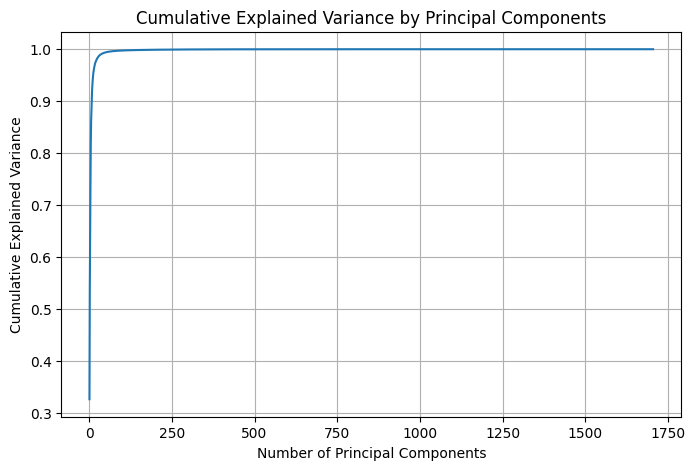

In [46]:
# Plot cumulative explained variance

plt.figure(figsize=(8, 5))

plt.plot(range(1, len(cumulative_variance) + 1),cumulative_variance)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance by Principal Components")

plt.grid(True)
plt.show()

In [47]:
# Find the number of components needed to retain different amounts of variance

for threshold in [0.90, 0.95, 0.99]:
    n_components = np.argmax(cumulative_variance >= threshold) + 1
    print(f"Components needed for {threshold * 100:.0f}% variance:",n_components)

Components needed for 90% variance: 8
Components needed for 95% variance: 13
Components needed for 99% variance: 36


In [48]:
# Select the number of principal components for the final analysis

n_components = 13

X_train_pca_final = X_train_pca[:, :n_components]

X_test_pca_final = pca.transform(X_test_preprocessed)[:, :n_components]

In [49]:
# Check the shape of the final PCA datasets

print("Final PCA training shape:", X_train_pca_final.shape)
print("Final PCA testing shape:", X_test_pca_final.shape)

Final PCA training shape: (1705, 13)
Final PCA testing shape: (427, 13)


In [50]:
# Check the cumulative variance retained by the final 13 components

final_explained_variance = cumulative_variance[n_components - 1]

print(
    f"Cumulative explained variance retained: "
    f"{final_explained_variance:.4f}"
)
print(
    f"Percentage of variance retained: "
    f"{final_explained_variance * 100:.2f}%"
)

Cumulative explained variance retained: 0.9558
Percentage of variance retained: 95.58%


### Interpretation

The original feature space contained 1,816 unique EEG-derived features with substantially different statistical properties. Because the `moments_*` features exhibited particularly severe skewness, they were processed separately using a QuantileTransformer, while the remaining features were scaled using RobustScaler. This family-aware approach provided a more appropriate preprocessing strategy than applying a single transformation to all feature families.

PCA was then fitted using the preprocessed training data and used to transform both the training and testing data. The results showed that 8 components were required to retain 90% of the variance, 13 components retained 95.58%, and 36 components retained 99%.

The first 13 principal components were therefore selected for subsequent modelling, reducing the feature representation from 1,816 dimensions to 13 while retaining 95.58% of the variance in the preprocessed training feature space. This substantially reduced dimensionality and produced a more manageable representation for machine-learning classification.

## Model Development

After preprocessing and Principal Component Analysis (PCA), the original 1,816 EEG-derived features were reduced to 13 principal components while retaining 95.58% of the total variance.

The next stage is to develop machine-learning models to classify the EEG samples into three observed classes:

* **NEGATIVE**
* **NEUTRAL**
* **POSITIVE**

A Logistic Regression model will first be developed as a baseline. Establishing a baseline provides a reference point for evaluating the performance of more complex models later in the analysis.

The model will be trained using the training data and evaluated on the held-out testing data.


### Create the Logistic Regression model

In [51]:
# Import Logistic Regression

from sklearn.linear_model import LogisticRegression

# Create the baseline Logistic Regression model

logistic_model = LogisticRegression(max_iter=5000,random_state=42)

### Train the model

In [52]:
# Train the Logistic Regression model

logistic_model.fit( X_train_pca_final,y_train)

LogisticRegression(max_iter=5000, random_state=42)

In [53]:
# Make predictions on the training data

y_train_pred = logistic_model.predict(X_train_pca_final)



In [54]:
# Calculate training accuracy

from sklearn.metrics import accuracy_score

train_accuracy = accuracy_score(y_train,y_train_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")

Training Accuracy: 0.8393


### Testing prediction

In [55]:
# Make predictions on the test data

y_pred = logistic_model.predict(X_test_pca_final)

# Calculate testing accuracy

test_accuracy = accuracy_score(y_test,y_pred)

print(f"Testing Accuracy: {test_accuracy:.4f}")

Testing Accuracy: 0.8337


In [56]:
# Generate the classification report

from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

    NEGATIVE       0.87      0.77      0.82       142
     NEUTRAL       0.89      0.95      0.92       143
    POSITIVE       0.74      0.77      0.76       142

    accuracy                           0.83       427
   macro avg       0.83      0.83      0.83       427
weighted avg       0.83      0.83      0.83       427



### Confusion Matrix

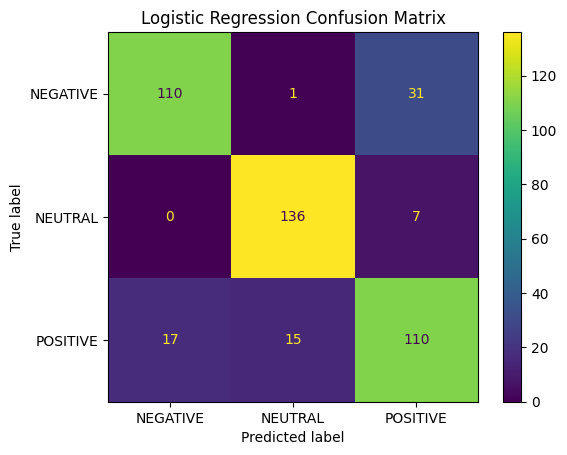

In [57]:
# Import confusion matrix tools

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate and display the confusion matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=logistic_model.classes_
)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [58]:
# Convert the classification report into a DataFrame

report = classification_report(y_test,y_pred,output_dict=True)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
NEGATIVE,0.866142,0.774648,0.817844,142.000000
NEUTRAL,0.894737,0.951049,0.922034,143.000000
POSITIVE,0.743243,0.774648,0.758621,142.000000
accuracy,0.833724,0.833724,0.833724,0.833724
macro avg,0.834707,0.833448,0.832833,427.000000
weighted avg,0.834848,0.833724,0.833042,427.000000


#### Interpretation

The Logistic Regression model was developed as a baseline classifier using the 13 principal components obtained from PCA. The model achieved an accuracy of 83.93% on the training data and 83.37% on the unseen testing data. The small difference of 0.56 percentage points between the training and testing accuracies indicates that the model generalizes well, with no strong evidence of overfitting.

The classification results showed differences in performance across the three emotional classes. The NEUTRAL class achieved the strongest performance, with a precision of 0.895, recall of 0.951, and F1-score of 0.922. The NEGATIVE class achieved a precision of 0.866, recall of 0.775, and F1-score of 0.818, while the POSITIVE class had the lowest performance, with a precision of 0.743, recall of 0.775, and F1-score of 0.759.

The confusion matrix showed that the model classified most NEUTRAL samples correctly, while more classification errors occurred between the NEGATIVE and POSITIVE classes. This suggests that the current PCA representation and Logistic Regression model capture useful patterns for distinguishing the three emotional states, but some overlap remains between the classes.

Overall, the Logistic Regression model provides a strong baseline performance of 83.37% test accuracy. This baseline will serve as a reference for evaluating whether more complex machine learning models can improve classification performance.

## Model Comparison and Final Analysis

The Logistic Regression model established a baseline test accuracy of 83.37%. In this step, an additional machine learning model will be developed and evaluated using the same PCA-reduced feature representation.

The performance of the models will be compared using accuracy, precision, recall, F1-score, and confusion matrices. This comparison will help determine whether more flexible models can improve upon the Logistic Regression baseline and provide better classification of the NEGATIVE, NEUTRAL, and POSITIVE emotional states.

### Import Random Forest and Create the model

In [59]:
# Import Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

### Train the Random Forest

In [60]:
# Train the Random Forest model

random_forest_model.fit(X_train_pca_final,y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [61]:
# Make predictions on the training data

y_train_pred_rf = random_forest_model.predict(X_train_pca_final)

# Calculate training accuracy

train_accuracy_rf = accuracy_score(y_train,y_train_pred_rf)

print(f"Random Forest Training Accuracy: {train_accuracy_rf:.4f}")

Random Forest Training Accuracy: 1.0000


### Testing performance

In [62]:
# Make predictions on the test data

y_pred_rf = random_forest_model.predict(X_test_pca_final)

# Calculate testing accuracy

test_accuracy_rf = accuracy_score(y_test,y_pred_rf)

print(f"Random Forest Testing Accuracy: {test_accuracy_rf:.4f}")

Random Forest Testing Accuracy: 0.8970


### Random Forest classification report

In [63]:
# Generate the Random Forest classification report

print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

    NEGATIVE       0.90      0.91      0.91       142
     NEUTRAL       0.95      0.92      0.94       143
    POSITIVE       0.84      0.86      0.85       142

    accuracy                           0.90       427
   macro avg       0.90      0.90      0.90       427
weighted avg       0.90      0.90      0.90       427



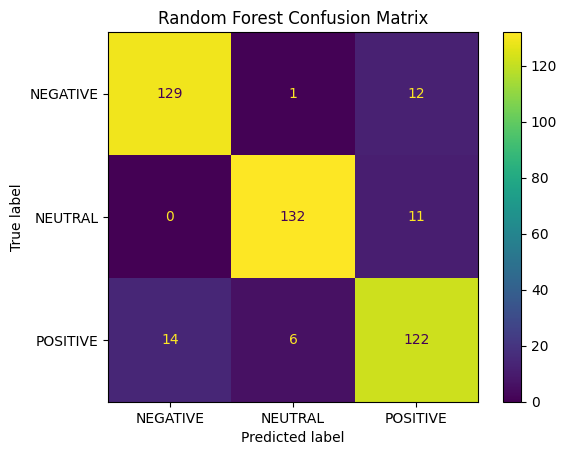

In [64]:
# Calculate and display the Random Forest confusion matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=random_forest_model.classes_
)

disp_rf.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [65]:
# Display the Random Forest confusion matrix with class labels

cm_rf_df = pd.DataFrame(
    cm_rf,
    index=random_forest_model.classes_,
    columns=random_forest_model.classes_
)

cm_rf_df

,NEGATIVE,NEUTRAL,POSITIVE
NEGATIVE,129,1,12
NEUTRAL,0,132,11
POSITIVE,14,6,122


### Interpretation

The Random Forest model achieved a training accuracy of 100.00% and a testing accuracy of 89.70%. The higher training accuracy indicates that the model was able to learn complex patterns in the training data, while the lower testing accuracy indicates some degree of overfitting. However, the model still generalized substantially better than the Logistic Regression baseline.

Compared with Logistic Regression, which achieved a testing accuracy of 83.37%, Random Forest improved testing accuracy by 6.33 percentage points. This indicates that the nonlinear decision boundaries learned by Random Forest were better suited to the patterns represented in the PCA-reduced feature space than the linear decision boundary used by Logistic Regression.

The classification report showed strong performance across all three classes. NEUTRAL achieved the highest F1-score of 0.94, followed by NEGATIVE at 0.91 and POSITIVE at 0.85. The confusion matrix showed that 129 of 142 NEGATIVE samples, 132 of 143 NEUTRAL samples, and 122 of 142 POSITIVE samples were correctly classified.

The remaining errors were distributed across the classes, with the largest single source of confusion being POSITIVE samples classified as NEGATIVE. This indicates that although the Random Forest model distinguishes the three classes better than the Logistic Regression baseline, some overlap between the class patterns remains.

Overall, Random Forest provided the best performance among the models evaluated so far, achieving 89.70% testing accuracy compared with 83.37% for Logistic Regression. This result suggests that nonlinear classification methods can make better use of the information retained in the 13 PCA components. However, the 10.30 percentage-point difference between training and testing accuracy should be considered when assessing the model's generalization.

## Final Model Comparison, Conclusions and Limitations

This final step brings together the results from the preprocessing, PCA, and machine learning stages of the project. The performance of the Logistic Regression and Random Forest models will be compared to identify the stronger classification approach.

The final results will then be used to summarize the main findings of the analysis, discuss the limitations of using this EEG-derived feature dataset, and identify possible directions for future work.

### Model comparison

In [66]:
# Compare the performance of the evaluated models

model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Training Accuracy": [train_accuracy, train_accuracy_rf],
    "Testing Accuracy": [test_accuracy, test_accuracy_rf]
})

model_comparison

,Model,Training Accuracy,Testing Accuracy
0,Logistic Regression,0.839296,0.833724
1,Random Forest,1.000000,0.896956


In [67]:
# Calculate the improvement in testing accuracy

accuracy_improvement = test_accuracy_rf - test_accuracy

print(f"Testing accuracy improvement: {accuracy_improvement:.4f}")
print(f"Testing accuracy improvement: {accuracy_improvement * 100:.2f}percentage points")

Testing accuracy improvement: 0.0632
Testing accuracy improvement: 6.32percentage points


### Final Interpretation

The comparison between the two evaluated models showed a clear difference in classification performance. Logistic Regression achieved a testing accuracy of 83.37%, while Random Forest achieved 89.70%, representing an improvement of 6.32 percentage points.

Logistic Regression showed very similar training and testing performance, with accuracies of 83.93% and 83.37%, respectively. This indicates relatively good generalization but also suggests that its linear decision boundary may not fully capture the relationships present in the PCA-reduced feature space.

Random Forest achieved 100.00% training accuracy and 89.70% testing accuracy. Although the difference between training and testing performance indicates some overfitting, the Random Forest still generalized substantially better to unseen data than Logistic Regression.

The results therefore indicate that the EEG-derived feature representation contains nonlinear patterns that were better captured by the Random Forest model. Among the models evaluated in this project, Random Forest produced the strongest classification performance.

Taken together, these findings provide empirical support for the alternative hypothesis (H₁), which proposed that EEG-derived features contain systematic patterns that can distinguish between the NEGATIVE, NEUTRAL, and POSITIVE classes. However, this support should be interpreted within the limitations of the dataset and validation strategy.

### Project Conclusion

This project investigated whether EEG-derived features could be used to distinguish between three experimental emotional states: NEGATIVE, NEUTRAL, and POSITIVE.

The analysis began with 2,548 EEG-derived features. Exploratory analysis revealed substantial redundancy, with 732 exact duplicate feature columns identified and removed, leaving 1,816 unique features. The remaining feature space contained substantial skewness, with 364 features having an absolute skewness greater than 5. Particularly extreme values were observed within the high-order `moments_*` feature family, which created numerical challenges during preprocessing and strongly influenced classical PCA.

A systematic preprocessing and dimensionality-reduction process was therefore developed. After feature-family-aware preprocessing and scaling, PCA was used to reduce the 1,816-dimensional feature space to 13 principal components while retaining 95.58% of the variance in the training data.

Two classification models were then evaluated using the same PCA-reduced representation. Logistic Regression achieved a testing accuracy of 83.37%, providing a useful linear baseline. Random Forest achieved a higher testing accuracy of 89.70%, representing an improvement of 6.32 percentage points.

The results demonstrate that the EEG-derived feature representation contains useful information for distinguishing the three experimental states. The stronger performance of Random Forest also suggests that nonlinear relationships within the reduced feature space may be important for classification.

Overall, the project demonstrates a complete machine learning workflow from exploratory data analysis and feature-quality investigation through preprocessing, dimensionality reduction, model development, and evaluation. More importantly, the preprocessing challenges encountered during the analysis highlighted the importance of understanding the statistical properties of high-dimensional EEG-derived features before applying dimensionality-reduction techniques.

### Limitations

Several limitations should be considered when interpreting the results of this project.

1. **EEG-derived features rather than raw EEG**

   The analysis was performed on pre-extracted EEG features rather than raw EEG recordings. Therefore, the project does not examine the original neural signals or perform raw EEG preprocessing such as filtering, artifact removal, or frequency-band extraction.

2. **Acute experimental states**

   The dataset represents short-term experimental cognitive and emotional states rather than chronic psychological stress. Therefore, the results should not be interpreted as evidence about chronic stress, long-term stress-related changes in the brain, or clinical conditions.

3. **Limited sample size**

   The dataset contains 2,132 observations originating from 40 participants. Although the number of observations is sufficient for this classification experiment, the relatively small number of participants limits how confidently the results can be generalized to a broader population.

4. **Potential participant-level dependence**

   Multiple observations originate from the same participants. Consequently, observations may not be completely independent. A participant-aware validation strategy would be preferable for determining how well the model generalizes to entirely unseen individuals.

5. **PCA is unsupervised**

   PCA selects components based on variance rather than class discrimination. Therefore, the 95.58% variance retained does not necessarily mean that 95.58% of the information relevant to classification was retained.

6. **Random Forest overfitting**

   The Random Forest achieved 100% training accuracy compared with 89.70% testing accuracy. This indicates some degree of overfitting and suggests that further validation or hyperparameter tuning would be useful before considering the model robust.

7. **Limited model comparison**

   Only Logistic Regression and Random Forest were evaluated. Other approaches, such as Support Vector Machines or other nonlinear classifiers, could potentially produce different results.